In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('50_Startups.csv')

In [3]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [4]:
df.shape

(50, 5)

In [5]:
df.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.1 KB


In [7]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
# One-Hot Encoding

df = pd.get_dummies(df, columns = ['State'], drop_first = True)

In [10]:
df.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False


In [13]:
df.corr()['Profit']

R&D Spend          0.972900
Administration     0.200717
Marketing Spend    0.747766
Profit             1.000000
State_Florida      0.116244
State_New York     0.031368
Name: Profit, dtype: float64

In [11]:
X = df.drop('Profit', axis = 1)
y = df['Profit']

In [12]:
X.corr()

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
R&D Spend,1.000000,0.241955,0.724248,0.105711,0.039068
Administration,0.241955,1.000000,-0.032154,0.010493,0.005145
Marketing Spend,0.724248,-0.032154,1.000000,0.205685,-0.033670
State_Florida,0.105711,0.010493,0.205685,1.000000,-0.492366
State_New York,0.039068,0.005145,-0.033670,-0.492366,1.000000


In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42)

In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
lr = LinearRegression()

In [18]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 0.81, -0.07, 0.03,938.79, 6.99]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['R&D Spend','Administration','Marketing Spend','State_Florida', 'State_New York']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.403e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [19]:
print(f"Intercept: {lr.intercept_}")
print(f"Coefficients: {lr.coef_}")

Intercept: 54028.03959364583
Coefficients: [ 8.05630064e-01 -6.87878823e-02  2.98554429e-02  9.38793006e+02
  6.98775997e+00]


In [20]:
y_pred = lr.predict(X_test)

In [21]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [22]:
mae = mean_absolute_error(y_test , y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

n = len(y_test)
k = X_test.shape[1]
adjusted_r2 = 1 - (((1 - r2) * (n - 1)) / (n - k - 1))

In [23]:
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.4f}")
print(f"Adjusted R-squared: {adjusted_r2:.4f}")

Mean Absolute Error (MAE): 6961.48
Root Mean Squared Error (RMSE): 9055.96
R-squared (R2): 0.8987
Adjusted R-squared: 0.7721


In [26]:
residuals = y_test - y_pred

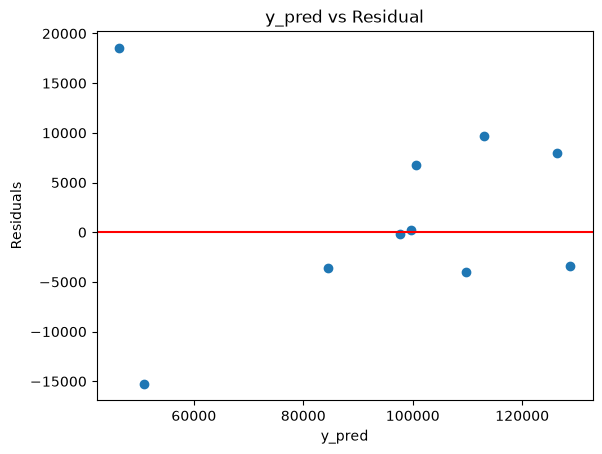

In [27]:
plt.scatter(y_pred , residuals)
plt.axhline(y=0, color = 'red')
plt.xlabel("y_pred")
plt.ylabel('Residuals')
plt.title('y_pred vs Residual')
plt.show()

In [29]:
residuals.sort_values(key = abs, ascending = False)                     # OR residuals.abs().sort_values(ascending = False)

45    18568.619314
48   -15239.007419
19     9679.434756
13     7944.470917
25     6761.097184
26    -4007.810327
39    -3602.693836
17    -3380.112885
30      260.095749
32     -171.435746
Name: Profit, dtype: float64

In [31]:
df.loc[45]

R&D Spend            1000.23
Administration     124153.04
Marketing Spend      1903.93
Profit              64926.08
State_Florida          False
State_New York          True
Name: 45, dtype: object

In [32]:
df.loc[48]

R&D Spend            542.05
Administration     51743.15
Marketing Spend         0.0
Profit             35673.41
State_Florida         False
State_New York         True
Name: 48, dtype: object

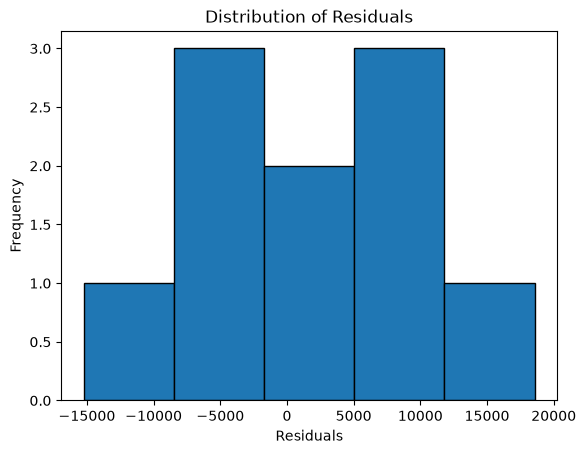

In [33]:
plt.hist(residuals, bins = 5, edgecolor = 'black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.show()